In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[-9.82230729,  1.02989243],
       [-0.32237366, -1.05394467],
       [-3.31672266,  0.4122302 ],
       ...,
       [-1.07625899,  0.80060393],
       [-8.89766794,  1.67360729],
       [-8.2453333 ,  2.08892348]], shape=(1000, 2))

In [5]:
y

array([1, 0, 2, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 2, 0, 2, 2,
       2, 0, 1, 2, 2, 0, 0, 2, 0, 1, 0, 2, 0, 0, 1, 0, 0, 1, 2, 1, 2, 1,
       1, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 0, 0, 0,
       1, 0, 0, 2, 2, 2, 0, 1, 0, 2, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       2, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2,
       1, 1, 1, 2, 1, 2, 0, 2, 2, 2, 0, 2, 2, 2, 1, 1, 2, 1, 2, 0, 1, 1,
       0, 0, 2, 2, 2, 0, 0, 0, 1, 0, 1, 2, 0, 0, 2, 2, 1, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 0, 0, 1, 2, 2, 1, 1, 2, 1, 0, 2, 0, 0, 1, 0, 1, 0, 0,
       1, 2, 1, 1, 2, 2, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 2, 2, 2, 1, 0, 1, 2, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 1,
       2, 2, 2, 0, 0, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 2, 2,
       0, 1, 2, 2, 1, 0, 2, 1, 2, 2, 2, 1, 2, 0, 0, 1, 2, 1, 2, 2, 1, 1,
       2, 2, 1, 1, 1, 0, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 0, 2, 1,
       2, 1, 0, 2, 0, 2, 0, 1, 1, 2, 0, 1, 1, 0, 0,

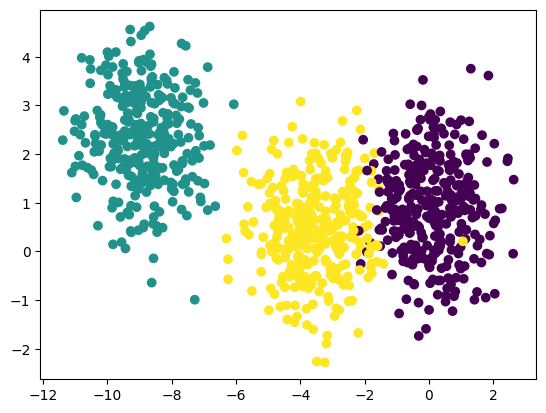

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [13]:
wcss

[1340.0,
 544.00064089531,
 361.2240124648078,
 297.839045961869,
 223.04313938845652,
 219.09817490768341,
 157.06111879407675,
 134.4038227042967,
 120.77688733210664,
 101.13739776962974]

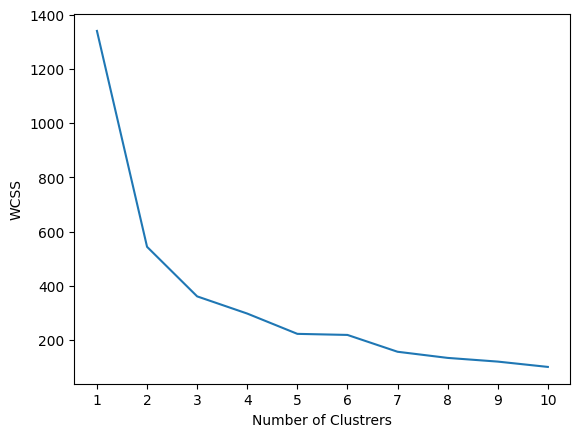

In [14]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([0, 2, 1, 1, 0, 0, 1, 0, 2, 1, 2, 1, 2, 0, 1, 2, 2, 1, 1, 2, 2, 2,
       1, 2, 2, 0, 2, 2, 1, 1, 0, 1, 2, 2, 0, 2, 1, 1, 1, 2, 2, 2, 0, 0,
       0, 1, 1, 0, 2, 0, 1, 2, 0, 1, 2, 0, 2, 1, 2, 1, 2, 0, 0, 0, 2, 1,
       1, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 2, 0, 0, 2, 2,
       0, 0, 2, 1, 0, 1, 2, 2, 1, 2, 1, 0, 0, 2, 1, 0, 2, 1, 2, 2, 0, 0,
       1, 2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 1, 0, 0, 2, 2, 2, 1, 0, 0, 1, 2,
       1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2,
       2, 0, 2, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 2, 1, 0, 0, 2,
       1, 1, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 2, 0, 0, 0, 1, 2,
       0, 0, 2, 1, 2, 1, 1, 0, 2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 2,
       1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 2, 0,
       2, 1, 0, 0, 0, 2, 2, 1, 2, 1, 1, 2, 2, 2, 0, 2, 1, 1, 2, 2, 1, 2,
       2, 1, 0, 0, 2, 1, 0, 0, 1, 1, 1, 2, 0, 1, 1, 1, 2, 1, 1, 2, 0, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2,

In [17]:
y_pred=kmeans.predict(X_test_scaled)

In [18]:
y_pred

array([1, 2, 1, 1, 1, 1, 0, 2, 1, 2, 0, 1, 1, 1, 1, 0, 2, 2, 2, 0, 1, 2,
       0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 1, 2,
       1, 0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 2, 0, 0, 2, 1, 1, 0, 0, 1,
       2, 0, 0, 2, 0, 1, 1, 2, 1, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 1, 2, 1,
       2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 1,
       2, 0, 0, 0, 1, 2, 2, 2, 0, 1, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1, 1, 2,
       0, 2, 2, 0, 2, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 2, 0, 0,
       1, 0, 1, 0, 1, 2, 0, 0, 0, 2, 2, 2, 1, 1, 0, 0, 1, 0, 2, 0, 1, 1,
       2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 1, 1, 0, 2, 1,
       1, 0, 2, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 0, 2, 0, 1, 2, 0, 1, 0, 1,
       0, 1, 1, 2, 2, 0, 2, 2, 2, 1, 2, 0, 1, 1, 0, 0, 2, 1, 1, 0, 2, 0,
       1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 2, 2, 0, 2, 0, 1, 0, 1, 0, 1, 0, 1,
       2, 2, 1, 1, 2, 1, 2, 1, 0, 0, 2, 1, 0, 1, 2,

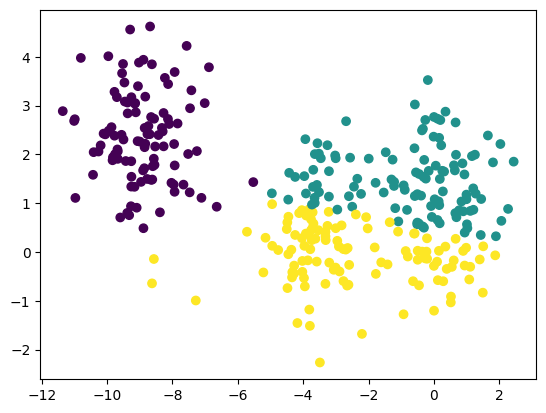

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [20]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [21]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from kneed import KneeLocator

In [23]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [24]:
kl.elbow

np.int64(3)

In [25]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [27]:
silhouette_coefficients

[0.5383297629256761,
 0.4488436731770925,
 0.40599875546080394,
 0.3981801891824518,
 0.36478775752180737,
 0.39589951883477953,
 0.4121610068188536,
 0.4039687856567559,
 0.39798400714381943]

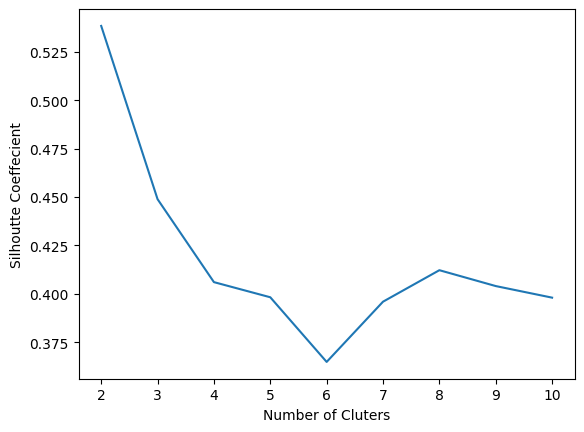

In [28]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()